# 03. EDA PaySim : distributions et trois hypothèses
On regarde d'abord la cible et les variables principales une par une, puis on teste trois hypothèses bivariées. Chaque test a son graphique, sa taille d'effet et un IC à 95 %. Le PDF de l'atelier sert de référence pédagogique ; le SQL et la modélisation ne sont pas dans ce notebook.

Les hypothèses viennent de `data_canvas.md` et de `02_documentation_data.ipynb`. Chaque ligne est une transaction simulée. Les montants restent dans l'unité du simulateur, sans conversion en euros.

Protocole. Les statistiques descriptives portent sur le fichier complet. Les tests portent sur un échantillon aléatoire de 500 000 transactions, stratifié par `isFraud` en proportion, graine 42, sans rééquilibrage. Les trois p-values sont corrigées par Holm (seuil familial de 5 %). Les IC à 95 % sont individuels, sans correction simultanée. Tests et IC supposent des transactions indépendantes : les comptes répétés et la dépendance temporelle peuvent donc rendre les IC trop étroits. Tout cela décrit la simulation, pas une vraie population bancaire. Pour une évaluation prédictive plus tard, il faudra refaire l'EDA sur le seul jeu d'entraînement, après un découpage justifié.

Dépendances : `pandas numpy scipy matplotlib nbformat` (à installer dans l'environnement Jupyter si besoin).

In [1]:
from pathlib import Path
import os, hashlib, json, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from IPython.display import display, Markdown, Image
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'docs/data_canvas.md').exists())
OUT = ROOT / 'docs/eda_figures'
OUT.mkdir(exist_ok=True)
SEED, SAMPLE_N, B = 42, 500_000, 1000
rng = np.random.default_rng(SEED)
# Chemin explicite via PAYSIM_CSV, copie du projet, fichier voisin ou cache KaggleHub.
filename = 'PS_20174392719_1491204439457_log-2.csv'
candidates = [Path(os.environ['PAYSIM_CSV'])] if os.environ.get('PAYSIM_CSV') else []
candidates += [ROOT / 'docs/sources' / filename, ROOT.parent / filename]
cache = Path.home() / '.cache/kagglehub/datasets/ealaxi/paysim1/versions'
if cache.exists():
    candidates += sorted(cache.glob('*/' + filename), reverse=True)
CSV = next((p for p in candidates if p.is_file()), None)
if CSV is None:
    raise FileNotFoundError("Exécuter l'extraction puis définir PAYSIM_CSV vers le CSV local.")
h = hashlib.sha256()
with CSV.open('rb') as f:
    for block in iter(lambda: f.read(1024*1024), b''): h.update(block)
lineage = json.loads((ROOT / 'docs/journal_lineage.json').read_text())
expected = next(x['sha256'] for x in lineage if x['source'] == 'PaySim')
assert h.hexdigest() == expected, 'CSV différent du fichier documenté : vérifier la source.'
cols = ['isFraud','type','step','amount','oldbalanceOrg','oldbalanceDest']
df = pd.read_csv(CSV, usecols=cols, dtype={'isFraud':'int8','type':'category','step':'int16'})
assert df.isFraud.isin([0,1]).all() and not df[cols].isna().any().any()
assert (df[['amount','oldbalanceOrg','oldbalanceDest']] >= 0).all().all()
print(f"Source : {CSV.name} | SHA-256 : {h.hexdigest()} | {len(df):,} transactions")
print('Versions :', sys.version.split()[0], pd.__version__, np.__version__, scipy.__version__)
# Les soldes après transaction, la sortie de règle et les identifiants ne sont pas chargés.
def savefig(name):
    plt.tight_layout(); plt.savefig(OUT / (name + '.png'), bbox_inches='tight')
    display(Image(filename=str(OUT / (name + '.png')))); plt.close()
def wilson(k, n):
    k, n = np.asarray(k, dtype=float), np.asarray(n, dtype=float)
    z = stats.norm.ppf(.975); p = k/n
    center = (p + z*z/(2*n))/(1+z*z/n)
    half = z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/(1+z*z/n)
    return np.where(k == 0, 0, np.maximum(0, center-half)), np.where(k == n, 1, np.minimum(1, center+half))
results = []
def result(label, test, statistic, p, effect, value, low, high):
    results.append(dict(analyse=label, test=test, statistique=float(statistic),
                        p_brute=float(p), effet=effect, valeur=float(value),
                        IC95_bas=float(low), IC95_haut=float(high)))


Source : PS_20174392719_1491204439457_log-2.csv | SHA-256 : 16910f90577b0d981bf8ff289714510bb89bc71bff7d3f220f024e287e4eea6b | 6,362,620 transactions
Versions : 3.14.3 3.0.6 2.5.3 1.18.1


## 1. Analyse univariée de la cible

On affiche les effectifs et les proportions, sinon le graphique écrase la classe rare. L'IC de Wilson du taux est indicatif : il suppose un échantillonnage indépendant, alors que le taux observé sur le fichier est connu exactement.

Taux de fraude : 0.1291 % ; IC Wilson : [0.1263 ; 0.1319] %


,classe,effectif,pourcentage
0,Légitime (0),6354407,99.870918
1,Fraude (1),8213,0.129082


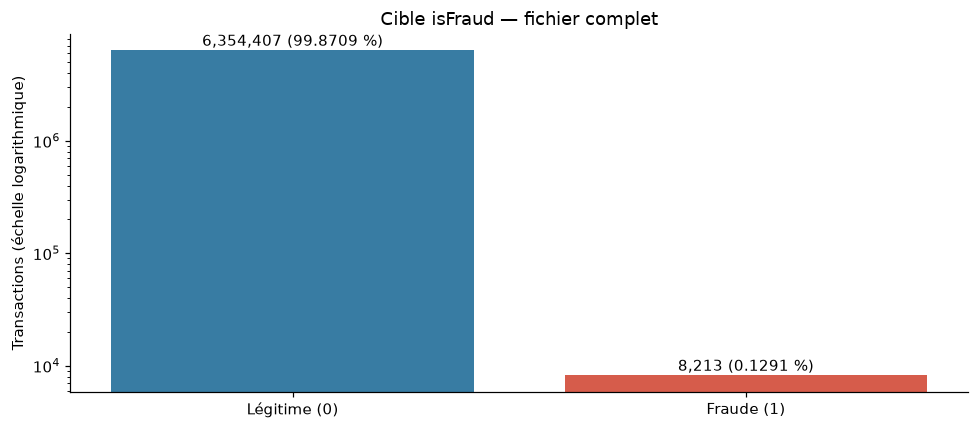

**Lecture :** la fraude est extrêmement minoritaire. Prédire systématiquement 0 donne une accuracy élevée sans détecter une seule fraude ; privilégier ensuite rappel, précision et PR-AUC.

In [2]:
counts = df.isFraud.value_counts().sort_index()
target = pd.DataFrame({'classe':['Légitime (0)','Fraude (1)'], 'effectif':counts.values})
target['pourcentage'] = 100*target.effectif/len(df)
display(target)
lo, hi = wilson(counts.loc[1], len(df))
print(f"Taux de fraude : {100*counts.loc[1]/len(df):.4f} % ; IC Wilson : [{100*lo:.4f} ; {100*hi:.4f}] %")
fig, ax = plt.subplots()
ax.bar(target.classe, target.effectif, color=['#387ca3','#d65c4b'])
ax.set_yscale('log'); ax.set_ylabel('Transactions (échelle logarithmique)')
ax.set_title('Cible isFraud (fichier complet)')
for i, row in target.iterrows(): ax.text(i, row.effectif*1.1, f"{row.effectif:,} ({row.pourcentage:.4f} %)", ha='center')
savefig('01_cible')
display(Markdown("Lecture : la fraude est extrêmement minoritaire. Un modèle qui prédit toujours 0 a une accuracy élevée et ne détecte aucune fraude. Pour la suite, on suivra plutôt le rappel, la précision et la PR-AUC."))


## 2. Analyse univariée des variables principales

`type` est nominale. `step` est un pas horaire simulé, pas une date réelle. `amount`, `oldbalanceOrg` et `oldbalanceDest` sont des montants à distribution asymétrique. Les tableaux portent sur toutes les lignes. Les histogrammes passent par `log1p`, qui rend les distributions lisibles et garde les zéros. Aucune valeur extrême n'est retirée, aucun zéro n'est imputé.

Rapports moyenne / médiane :
step               1.02
amount             2.40
oldbalanceOrg     58.69
oldbalanceDest     8.29
dtype: float64
Taux échantillon : 0.1290 %


,effectif,pourcentage
type,,
CASH_OUT,2237500,35.166331
PAYMENT,2151495,33.814608
CASH_IN,1399284,21.992261
TRANSFER,532909,8.375622
DEBIT,41432,0.651178


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,zeros_pct,manquants
step,6362620.0,2.433972e+02,1.423320e+02,1.0,9.0000,156.00,239.000,335.0000,4.900000e+02,6.810000e+02,7.430000e+02,0.000000,0
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,449.4676,13389.57,74871.940,208721.4775,5.186342e+05,1.615979e+06,9.244552e+07,0.000251,0
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.0000,0.00,14208.000,107315.1750,5.823702e+06,1.602726e+07,5.958504e+07,33.043762,0
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.0000,0.00,132705.665,943036.7075,5.147230e+06,1.237182e+07,3.560159e+08,42.504314,0


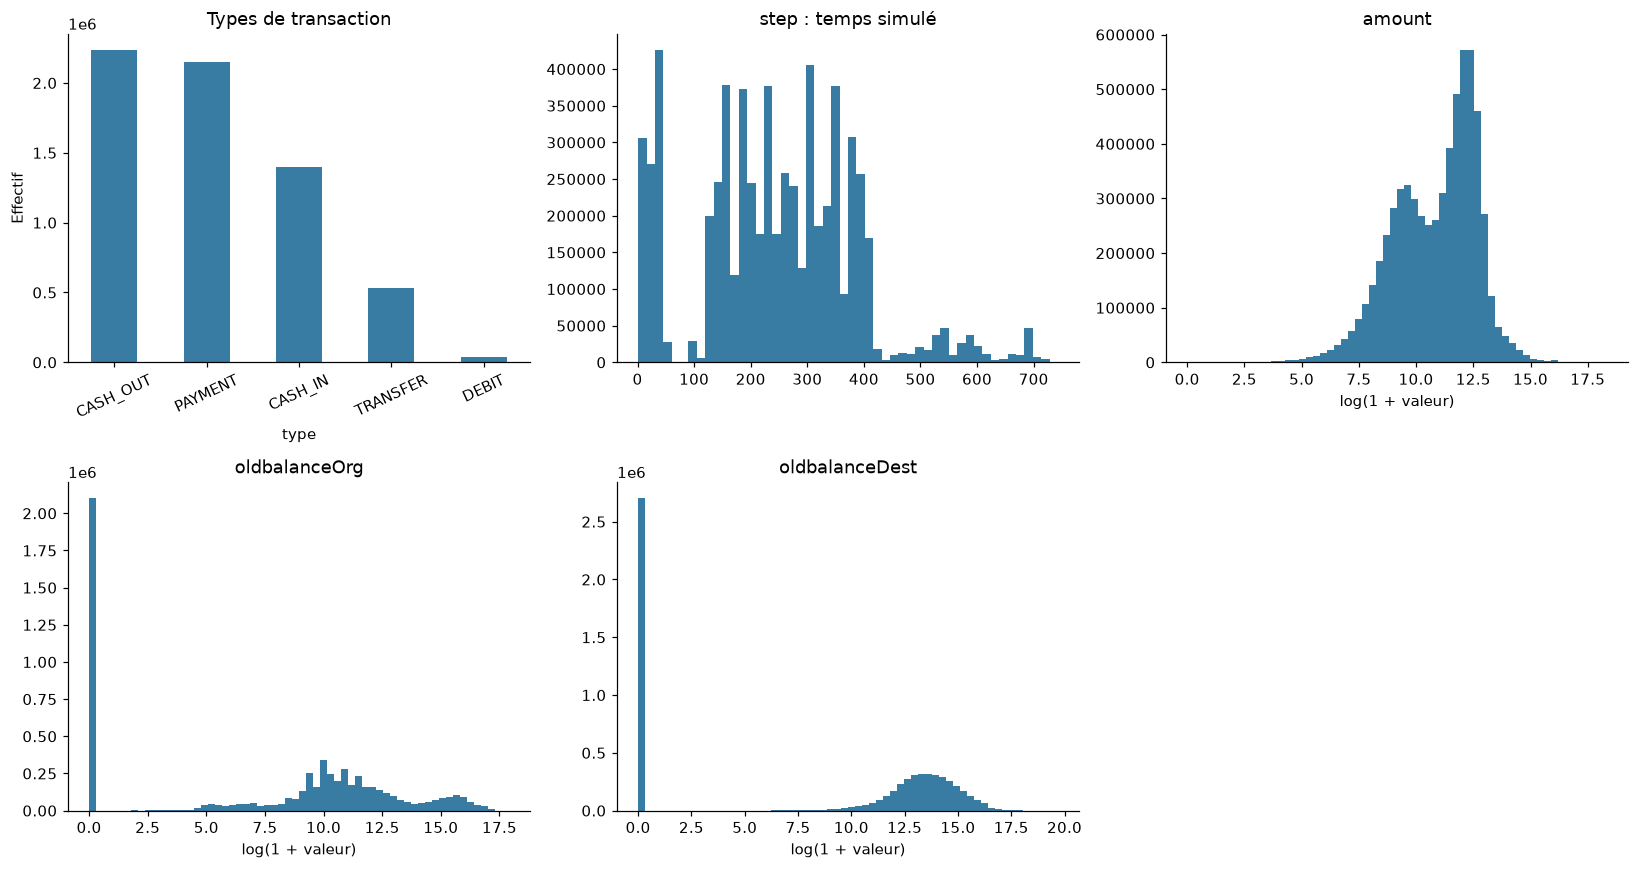

**Lecture :** comparer moyenne, médiane, P95 et maximum pour apprécier l'asymétrie. Les soldes nuls peuvent relever des conventions du simulateur. Les pics de `step` décrivent l'activité simulée ; les identifiants ne sont pas des quantités et leurs distributions ne sont pas interprétées comme telles.

,effectif échantillon
isFraud,
0,499355
1,645


In [3]:
types = df.type.value_counts().rename_axis('type').to_frame('effectif')
types['pourcentage'] = 100*types.effectif/len(df)
display(types)
quant = ['step','amount','oldbalanceOrg','oldbalanceDest']
desc = df[quant].describe(percentiles=[.01,.25,.5,.75,.95,.99]).T
desc['zeros_pct'] = df[quant].eq(0).mean()*100
desc['manquants'] = df[quant].isna().sum()
display(desc)
fig, axes = plt.subplots(2,3,figsize=(15,8))
types.effectif.plot.bar(ax=axes[0,0], color='#387ca3', rot=25)
axes[0,0].set_title('Types de transaction'); axes[0,0].set_ylabel('Effectif')
axes[0,1].hist(df.step,bins=50,color='#387ca3'); axes[0,1].set_title('step : temps simulé')
for ax, c in zip([axes[0,2],axes[1,0],axes[1,1]],quant[1:]):
    ax.hist(np.log1p(df[c]),bins=60,color='#387ca3'); ax.set_title(c); ax.set_xlabel('log(1 + valeur)')
axes[1,2].axis('off')
savefig('02_variables_principales')
print('Rapports moyenne / médiane :')
print((desc['mean']/desc['50%'].replace(0,np.nan)).round(2))
display(Markdown("Lecture : l'écart entre moyenne, médiane, P95 et maximum montre l'asymétrie. Les soldes nuls viennent peut-être des conventions du simulateur. Les pics de `step` décrivent l'activité simulée. Les identifiants ne sont pas des quantités, on n'interprète donc pas leur distribution."))
# Allocation proportionnelle exacte avec arrondi de la classe rare.
n1 = round(SAMPLE_N * counts.loc[1]/len(df))
eda = pd.concat([df[df.isFraud.eq(1)].sample(n=n1,random_state=SEED),
                 df[df.isFraud.eq(0)].sample(n=SAMPLE_N-n1,random_state=SEED)])
display(eda.groupby('isFraud',observed=True).size().to_frame('effectif échantillon'))
print(f'Taux échantillon : {100*eda.isFraud.mean():.4f} %')
del df


## 3. Bivariée 1 : type × isFraud

H1 : le type de transaction est associé à la fraude. H0 : le type et la cible sont indépendants. On calcule le χ² de Pearson sur la table 5 × 2. Si un effectif attendu passe sous 5, la p-value vient d'une calibration Monte-Carlo conditionnelle aux marges (19 999 tirages, graine 42, résolution minimale 1/20 000) au lieu de l'approximation asymptotique. Il faut SciPy ≥ 1.15. La taille d'effet est le V de Cramér, entre 0 et 1. Son IC percentile vient de 1 000 réplications bootstrap stratifiées par cible : dans chaque classe, on retire les types selon une loi multinomiale, ce qui revient au bootstrap des lignes pour cette table. Le graphique montre les taux avec leurs IC de Wilson et leurs dénominateurs.

χ²=1670.877, ddl=4, p=5e-05, attendu minimum=4.16
V=0.0578, IC95 bootstrap=[0.0542 ; 0.0616]


isFraud,légitimes,fraudes,total,taux_pct
type,,,,
CASH_IN,109944,0,109944,0.000000
CASH_OUT,175730,330,176060,0.187436
DEBIT,3228,0,3228,0.000000
PAYMENT,168833,0,168833,0.000000
TRANSFER,41620,315,41935,0.751163


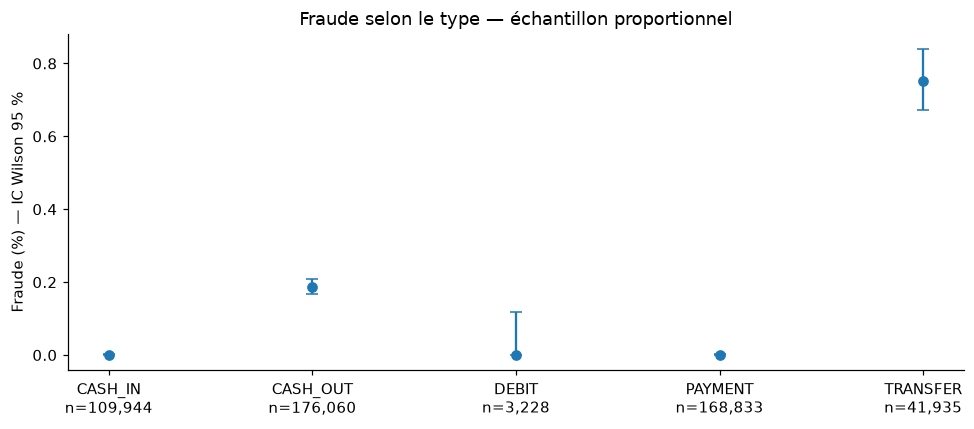

**Lecture :** examiner le taux par type et V ensemble : une p-value faible ne mesure pas la force de l'association. Zéro fraude observée pour un type ne démontre pas un risque nul ; la borne supérieure de Wilson reste positive.

In [4]:
ct = pd.crosstab(eda.type,eda.isFraud)
chi,p,dof,expected = stats.chi2_contingency(ct, correction=False)
test_name = 'χ² Pearson asymptotique'
if expected.min() < 5:
    # Calibration Monte-Carlo conditionnelle aux marges, sans approximation chi².
    mc = stats.chi2_contingency(ct, correction=False, method=stats.MonteCarloMethod(n_resamples=19999, rng=np.random.default_rng(SEED)))
    p = mc.pvalue
    test_name = 'χ² Pearson Monte-Carlo (19 999 tirages)'
def cramers_v(t):
    return np.sqrt(stats.chi2_contingency(t,correction=False)[0]/np.asarray(t).sum())
v = cramers_v(ct)
boot=[]
for _ in range(B):
    t = np.column_stack([rng.multinomial(int(ct[c].sum()),ct[c]/ct[c].sum()) for c in [0,1]])
    boot.append(cramers_v(t[t.sum(axis=1)>0]))
low,high = np.quantile(boot,[.025,.975])
result('type × cible',test_name,chi,p,'V de Cramér',v,low,high)
summary = ct.rename(columns={0:'légitimes',1:'fraudes'})
summary['total']=ct.sum(axis=1); summary['taux_pct']=100*ct[1]/summary.total
a,b = wilson(ct[1],summary.total)
display(summary)
fig,ax=plt.subplots()
ax.errorbar(range(len(ct)), summary.taux_pct,
            yerr=[summary.taux_pct-100*a,100*b-summary.taux_pct],fmt='o',capsize=4)
ax.set_xticks(range(len(ct)),[f'{t}\nn={n:,}' for t,n in zip(ct.index,summary.total)])
ax.set_ylabel('Fraude (%), IC Wilson 95 %'); ax.set_title('Fraude selon le type (échantillon proportionnel)')
savefig('03_type_cible')
print(f'χ²={chi:.3f}, ddl={dof}, p={p:.3g}, attendu minimum={expected.min():.2f}')
print(f'V={v:.4f}, IC95 bootstrap=[{low:.4f} ; {high:.4f}]')
display(Markdown("Lecture : les taux par type et V se lisent ensemble, car une p-value faible ne dit rien de la force de l'association. Un type sans fraude observée n'a pas pour autant un risque nul : la borne haute de Wilson reste positive."))


## 4. Bivariée 2 : amount × isFraud

H2 : la distribution des montants n'est pas la même pour les fraudes et pour les transactions légitimes. H0 : même distribution. Test de Mann–Whitney bilatéral, approximation asymptotique avec correction des ex æquo. Quand les deux distributions n'ont pas la même forme, ce test ne compare pas seulement les médianes.

Taille d'effet : corrélation bisérielle de rang, `r = 2U/(n_fraude × n_légitime) − 1`. Un r positif veut dire que les montants frauduleux ont tendance à être plus élevés. L'IC asymptotique à 95 % utilise la variance des placements de chaque groupe (c'est-à-dire la variance de l'estimateur de la probabilité de supériorité, ex æquo comptés pour moitié), puis passe de [0,1] à [−1,1]. Le boxplot est en `log1p` pour rester lisible ; le test et l'effet sont calculés sur les montants bruts.

U=259639839.5, p=1.48e-159, r=0.6122, IC95=[0.5749 ; 0.6496]
Probabilité de supériorité (égalité pour moitié) : 0.806


,count,mean,std,min,50%,95%,99%,max
isFraud,,,,,,,,
0,499355.0,1.787045e+05,5.906750e+05,0.01,75072.15,515576.832,1.604994e+06,69886731.3
1,645.0,1.460012e+06,2.344280e+06,119.00,474467.20,7290175.212,1.000000e+07,10000000.0


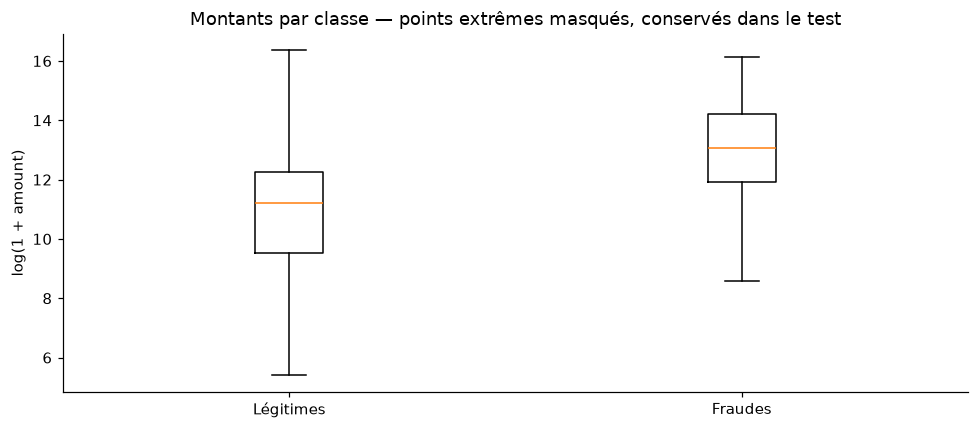

In [5]:
x=eda.loc[eda.isFraud.eq(1),'amount'].to_numpy()
y=eda.loc[eda.isFraud.eq(0),'amount'].to_numpy()
u,p=stats.mannwhitneyu(x,y,alternative='two-sided',method='asymptotic')
auc=u/(len(x)*len(y)); r=2*auc-1
sx,sy=np.sort(x),np.sort(y)
placements_x=(np.searchsorted(sy,x,'left')+np.searchsorted(sy,x,'right'))/(2*len(y))
placements_y=1-(np.searchsorted(sx,y,'left')+np.searchsorted(sx,y,'right'))/(2*len(x))
assert np.isclose(placements_x.mean(),auc) and np.isclose(placements_y.mean(),auc)
se=np.sqrt(placements_x.var(ddof=1)/len(x)+placements_y.var(ddof=1)/len(y))
low,high=2*np.clip([auc-1.96*se,auc+1.96*se],0,1)-1
result('amount × cible','Mann–Whitney bilatéral',u,p,'r bisériel de rang',r,low,high)
display(eda.groupby('isFraud',observed=True).amount.describe(percentiles=[.5,.95,.99]))
fig,ax=plt.subplots()
ax.boxplot([np.log1p(y),np.log1p(x)],tick_labels=['Légitimes','Fraudes'],showfliers=False)
ax.set_ylabel('log(1 + amount)'); ax.set_title('Montants par classe (points extrêmes masqués, conservés dans le test)')
savefig('04_amount_cible')
print(f'U={u:.1f}, p={p:.3g}, r={r:.4f}, IC95=[{low:.4f} ; {high:.4f}]')
print(f'Probabilité de supériorité (égalité pour moitié) : {auc:.3f}')


## 5. Bivariée 3 : relation montant / solde initial × isFraud

H3, sous forme testable : un montant égal au solde initial de l'émetteur est associé à la fraude. La condition est `montant_egal_solde = (oldbalanceOrg > 0) ET (|amount − oldbalanceOrg| ≤ 0,01)`. La tolérance absolue d'un centième d'unité a été fixée avant le test, et les couples zéro/zéro sont exclus. Cette définition ne teste qu'une forme précise de l'hypothèse, pas toutes les relations possibles entre montant et solde. Elle n'utilise que des valeurs d'avant l'exécution.

H0 : odds ratio = 1. Test exact de Fisher bilatéral sur la table 2 × 2. La taille d'effet est l'odds ratio (OR) de fraude entre les transactions qui remplissent la condition et les autres. IC de Wald sur log(OR) : `exp(log(OR) ± 1,96 √(1/a+1/b+1/c+1/d))`. Si une cellule vaut zéro, on ajoute 0,5 à chaque cellule (correction de Haldane–Anscombe), pour l'effet et l'IC seulement ; Fisher reste calculé sur la table brute. Un OR n'est pas un rapport de probabilités. Le graphique montre les risques absolus avec leurs IC de Wilson.

p Fisher=0, OR=38102337.848, IC95=[2283357.551 ; 635812883.863], correction +0,5 : True


isFraud,légitimes,fraudes
montant_egal_solde,,
False,499355,16
True,0,629


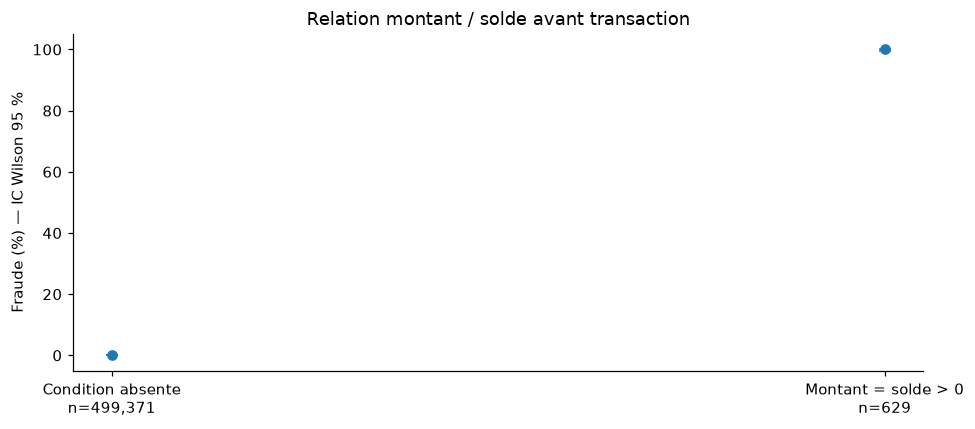

**Lecture :** l'association peut refléter directement les règles de génération de PaySim. Le solde initial est une variable candidate, mais sa disponibilité réelle et les conventions du simulateur doivent être vérifiées avant modélisation.

In [6]:
eda['montant_egal_solde'] = eda.oldbalanceOrg.gt(0) & np.isclose(eda.amount,eda.oldbalanceOrg,rtol=0,atol=.01)
t = pd.crosstab(eda.montant_egal_solde,eda.isFraud).reindex(index=[False,True],columns=[0,1],fill_value=0)
a,b,c,d = float(t.loc[True,1]),float(t.loc[True,0]),float(t.loc[False,1]),float(t.loc[False,0])
_,p=stats.fisher_exact([[a,b],[c,d]],alternative='two-sided')
values=np.array([a,b,c,d]); corrected=bool((values==0).any())
if corrected: values += .5
aa,bb,cc,dd=values
odds=aa*dd/(bb*cc); se=np.sqrt((1/values).sum())
low,high=np.exp(np.log(odds)+np.array([-1,1])*1.96*se)
result('montant = solde initial × cible','Fisher bilatéral',odds,p,'Odds ratio',odds,low,high)
display(t.rename(columns={0:'légitimes',1:'fraudes'}))
total=t.sum(axis=1); rate=t[1]/total
l,h=wilson(t[1],total)
fig,ax=plt.subplots()
ax.errorbar([0,1],100*rate,yerr=[100*(rate-l),100*(h-rate)],fmt='o',capsize=4)
ax.set_xticks([0,1],[f'Condition absente\nn={total.loc[False]:,}',f'Montant = solde > 0\nn={total.loc[True]:,}'])
ax.set_ylabel('Fraude (%), IC Wilson 95 %'); ax.set_title('Relation montant / solde avant transaction')
savefig('05_relation_solde_cible')
print(f'p Fisher={p:.3g}, OR={odds:.3f}, IC95=[{low:.3f} ; {high:.3f}], correction +0,5 : {corrected}')
display(Markdown("Lecture : cette association peut venir directement des règles de génération de PaySim. Le solde initial est une variable candidate, mais avant de modéliser il faut vérifier qu'il serait vraiment disponible et comprendre les conventions du simulateur."))


## 6. Synthèse des trois hypothèses et limites

Holm contrôle l'erreur familiale des trois tests, même s'ils sont dépendants. Une p-value affichée à 0 vient d'une limite numérique : la probabilité n'est pas exactement nulle. Les IC dépendent de l'hypothèse d'indépendance et, pour le bootstrap stratifié, des effectifs des classes. Une association statistique ne prouve pas de causalité, ni une utilité prédictive en dehors de la simulation.

In [7]:
res=pd.DataFrame(results)
order=np.argsort(res.p_brute.to_numpy()); adjusted=np.empty(len(res))
adjusted[order]=np.minimum(1,np.maximum.accumulate((len(res)-np.arange(len(res)))*res.p_brute.to_numpy()[order]))
res['p_Holm']=adjusted
res['conclusion']=np.where(res.p_Holm<.05,'Association soutenue dans PaySim','Association non démontrée')
res.to_csv(ROOT/'docs/eda_resultats.csv',sep=';',index=False)
display(res)
lines=['# Synthèse EDA PaySim', '', f'Échantillon proportionnel : {len(eda):,} lignes, dont {int(eda.isFraud.sum()):,} fraudes ; graine {SEED}.', '', 'Trois tests, correction de Holm ; IC individuels à 95 %.']
for row in res.itertuples():
    pv='< 1e-300 (sous-flux numérique)' if row.p_Holm==0 else f'{row.p_Holm:.3g}'
    msg=f"{row.analyse} : {row.test}, p corrigée {pv} ; {row.effet} = {row.valeur:.4g}, IC95 [{row.IC95_bas:.4g} ; {row.IC95_haut:.4g}]. {row.conclusion}."
    display(Markdown(msg)); lines += ['', '- '+msg]
lines += ['', 'Les résultats portent sur des données synthétiques. Les dépendances par compte et dans le temps ne sont pas prises en compte, donc les IC peuvent être trop étroits. Pas de résultat causal ni de validation prédictive. Les valeurs postérieures à la transaction sont exclues.']
synthesis_path = ROOT / 'docs/eda_synthese.md'
existing = synthesis_path.read_text() if synthesis_path.exists() else ''
marker = '\n## Analyse univariée'
editorial = marker + existing.split(marker, 1)[1] if marker in existing else ''
synthesis_path.write_text('\n'.join(lines) + '\n' + editorial)


,analyse,test,statistique,p_brute,effet,valeur,IC95_bas,IC95_haut,p_Holm,conclusion
0,type × cible,χ² Pearson Monte-Carlo (19 999 tirages),1.670877e+03,5.000000e-05,V de Cramér,5.780791e-02,5.422367e-02,6.157201e-02,5.000000e-05,Association soutenue dans PaySim
1,amount × cible,Mann–Whitney bilatéral,2.596398e+08,1.481563e-159,r bisériel de rang,6.122493e-01,5.749361e-01,6.495626e-01,2.963125e-159,Association soutenue dans PaySim
2,montant = solde initial × cible,Fisher bilatéral,3.810234e+07,0.000000e+00,Odds ratio,3.810234e+07,2.283358e+06,6.358129e+08,0.000000e+00,Association soutenue dans PaySim


**type × cible** : χ² Pearson Monte-Carlo (19 999 tirages), p corrigée 5e-05 ; V de Cramér = 0.05781, IC95 [0.05422 ; 0.06157]. Association soutenue dans PaySim.

**amount × cible** : Mann–Whitney bilatéral, p corrigée 2.96e-159 ; r bisériel de rang = 0.6122, IC95 [0.5749 ; 0.6496]. Association soutenue dans PaySim.

**montant = solde initial × cible** : Fisher bilatéral, p corrigée < 1e-300 (sous-flux numérique) ; Odds ratio = 3.81e+07, IC95 [2.283e+06 ; 6.358e+08]. Association soutenue dans PaySim.

### Interprétation des résultats exécutés

Univariée. Le fichier compte 8 213 fraudes sur 6 362 620 transactions (0,1291 %). Les moyennes dépassent les médianes, d'un facteur 2,40 pour le montant, 58,69 pour le solde émetteur et 8,29 pour le solde destinataire. D'où les échelles logarithmiques et le test de rang.

Type. V = 0,0578, IC95 [0,0542 ; 0,0616] : l'association globale est faible sur cette échelle, malgré une p-value corrigée de 0,00005. Avec une cible aussi rare, ce V se lit avec les taux par type. L'effectif attendu minimal est de 4,16, d'où la calibration Monte-Carlo ; la p-value est ici à sa résolution minimale.

Montant. r = 0,6122, IC95 [0,5749 ; 0,6496]. Un montant frauduleux dépasse un montant légitime tiré au hasard avec une probabilité estimée de 80,6 % (égalités comptées pour moitié). H2 est soutenue, sans que cela démontre une causalité.

Montant égal au solde initial positif. Dans cet échantillon, la table a une cellule nulle. L'OR affiché est donc corrigé par +0,5 : environ 38 millions, avec un IC très large [2,28 millions ; 636 millions]. Ce chiffre dépend beaucoup de la correction et ne se lit pas comme un multiplicateur de risque précis. H3 est soutenue pour cette définition. Mais la séparation est presque parfaite : avant tout usage prédictif, il faut regarder les règles de simulation et vérifier que le solde serait disponible. Et une séparation dans l'échantillon ne prouve pas une séparation parfaite dans tout le fichier.

Après correction de Holm, les trois hypothèses sont soutenues au seuil familial de 5 %, sous les hypothèses du protocole. Les données sont synthétiques et les transactions peut-être dépendantes, ce qui limite la portée de cette conclusion.